In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, os, joblib
from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from datetime import datetime


In [2]:
plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor":"#0d1117","axes.facecolor":"#0d1117","axes.edgecolor":"#30363d","axes.labelcolor":"#c9d1d9","text.color":"#c9d1d9","xtick.color":"#8b949e","ytick.color":"#8b949e","grid.color":"#21262d"})
def save_fig(name):
    t=datetime.now().strftime("%Y-%m-%d_%H-%M")
    os.makedirs("plots",exist_ok=True)
    plt.savefig(f"plots/{name}_{t}.png",dpi=150,bbox_inches="tight")
    print(f"  Saved plots/{name}_{t}.png")


In [3]:
train=pd.read_csv("VMAI_DURATION_Data.csv")
print(f"Shape: {train.shape}")
train.head()


Shape: (5000, 8)


,difficulty,importance,scheduled_duration,category,location,fixed_time,time_difference,real_duration
0,0.584,0.727,56,work,home,21:30,7.50,60.0
1,0.323,1.000,36,work,office,22:15,8.25,66.1
2,0.483,0.987,21,health,gym,NaN,-1.00,47.2
3,0.513,0.082,20,personal,store,NaN,-1.00,23.4
4,0.913,0.729,96,study,office,16:45,0.75,112.7


  Saved plots/distributions_2026-05-27_16-52.png


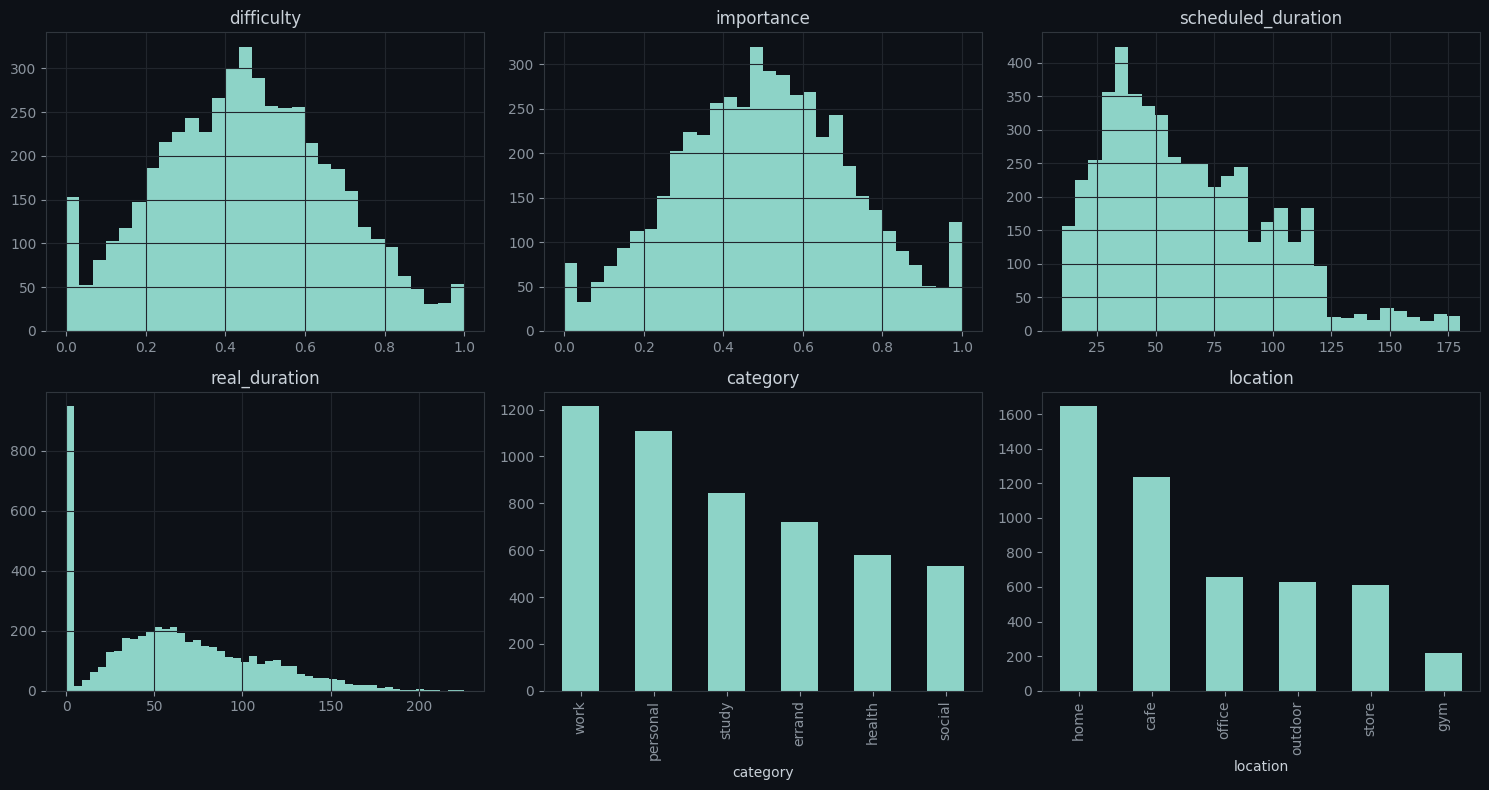

In [4]:
fig,axes=plt.subplots(2,3,figsize=(15,8))
train["difficulty"].hist(bins=30,ax=axes[0,0]);axes[0,0].set_title("difficulty")
train["importance"].hist(bins=30,ax=axes[0,1]);axes[0,1].set_title("importance")
train["scheduled_duration"].hist(bins=30,ax=axes[0,2]);axes[0,2].set_title("scheduled_duration")
train["real_duration"].hist(bins=50,ax=axes[1,0]);axes[1,0].set_title("real_duration")
train["category"].value_counts().plot(kind="bar",ax=axes[1,1]);axes[1,1].set_title("category")
train["location"].value_counts().plot(kind="bar",ax=axes[1,2]);axes[1,2].set_title("location")
plt.tight_layout()
save_fig("distributions")


  Saved plots/cat_loc_effects_2026-05-27_16-52.png


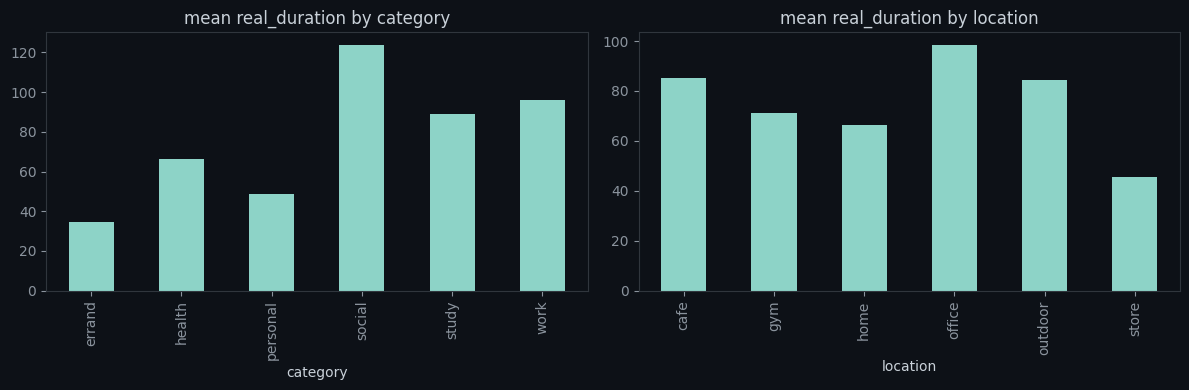

In [5]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
nz=train[train["real_duration"]>0]
nz.groupby("category")["real_duration"].mean().plot(kind="bar",ax=axes[0])
axes[0].set_title("mean real_duration by category")
nz.groupby("location")["real_duration"].mean().plot(kind="bar",ax=axes[1])
axes[1].set_title("mean real_duration by location")
plt.tight_layout()
save_fig("cat_loc_effects")


  Saved plots/correlation_2026-05-27_16-52.png


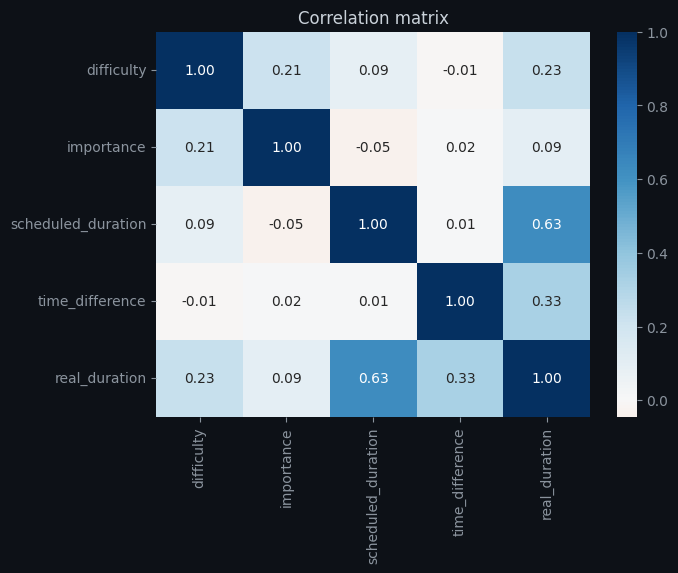

In [6]:
num_cols=["difficulty","importance","scheduled_duration","time_difference","real_duration"]
corr=train[num_cols].corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr,annot=True,cmap="RdBu",center=0,fmt=".2f")
plt.title("Correlation matrix")
save_fig("correlation")


In [7]:
X=train.drop("real_duration",axis=1)
y=train["real_duration"]
num_feats=["difficulty","importance","scheduled_duration","time_difference"]
cat_feats=["category","location"]
num_pipe=Pipeline([("imputer",SimpleImputer(strategy="constant",fill_value=-1))])
cat_pipe=Pipeline([("encoder",OneHotEncoder(handle_unknown="ignore",sparse_output=False))])
preprocessor=ColumnTransformer([("num",num_pipe,num_feats),("cat",cat_pipe,cat_feats)])
X_proc=preprocessor.fit_transform(X)
feat_names=num_feats+list(preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_feats))
print(f"Features: {X_proc.shape[1]} ({len(num_feats)} numeric + {X_proc.shape[1]-len(num_feats)} encoded)")


Features: 16 (4 numeric + 12 encoded)


In [8]:
X_train,X_test,y_train,y_test=train_test_split(X_proc,y,test_size=0.2,random_state=42)
print(f"Train: {X_train.shape[0]}  Test: {X_test.shape[0]}")
baseline=np.full_like(y,y.mean())
print(f"Baseline MAE: {mean_absolute_error(y,baseline):.4f}  R2: {r2_score(y,baseline):.4f}")


Train: 4000  Test: 1000
Baseline MAE: 37.2713  R2: 0.0000


/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning: [16:52:58] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


       model       MAE       R2
       Ridge 21.975101 0.604019
RandomForest  4.954573 0.965765
     XGBoost  4.781980 0.974870
  Saved plots/model_comparison_2026-05-27_16-52.png


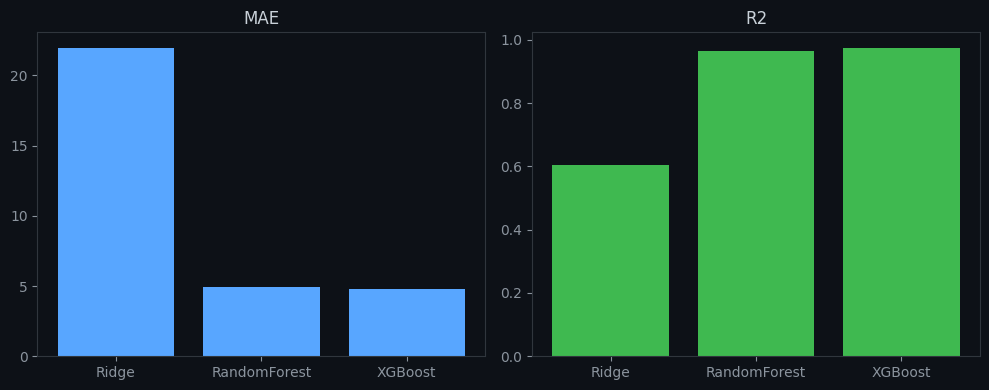

In [9]:
models={
    "Ridge":Ridge(alpha=1.0),
    "RandomForest":RandomForestRegressor(n_estimators=200,max_depth=15,min_samples_leaf=4,random_state=42,n_jobs=-1),
    "XGBoost":xgb.XGBRegressor(n_estimators=400,learning_rate=0.05,max_depth=10,subsample=0.8,colsample_bytree=0.8,random_state=42,device="cuda"),
}
results=[]
for name,m in models.items():
    m.fit(X_train,y_train)
    p=m.predict(X_test)
    results.append({"model":name,"MAE":mean_absolute_error(y_test,p),"R2":r2_score(y_test,p)})
res_df=pd.DataFrame(results)
print(res_df.to_string(index=False))
fig,axes=plt.subplots(1,2,figsize=(10,4))
colors=["#58a6ff","#3fb950","#f0883e"]
for i,metric in enumerate(["MAE","R2"]):
    axes[i].bar(res_df["model"],res_df[metric],color=colors[i])
    axes[i].set_title(metric)
plt.tight_layout()
save_fig("model_comparison")


In [10]:
param_grid={
    "n_estimators":[200,400],
    "max_depth":[6,10,14],
    "learning_rate":[0.03,0.05,0.1],
    "subsample":[0.7,0.8,1.0],
    "colsample_bytree":[0.7,0.8,1.0],
}
gs=xgb.XGBRegressor(random_state=42,device="cuda")
grid=GridSearchCV(gs,param_grid,cv=5,scoring="neg_mean_absolute_error",n_jobs=-1,verbose=1)
grid.fit(X_train,y_train)
print(f"Best params: {grid.best_params_}")
print(f"Best CV MAE: {-grid.best_score_:.4f}")
best_params=grid.best_params_


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.7}
Best CV MAE: 3.8891


In [ ]:
best_params = {'colsample_bytree': 1.0, 'learning_rate': 0.03, 'max_depth': 6, 'n_estimators': 400, 'subsample': 0.7}

  Saved plots/lr_sensitivity_2026-05-27_17-20.png


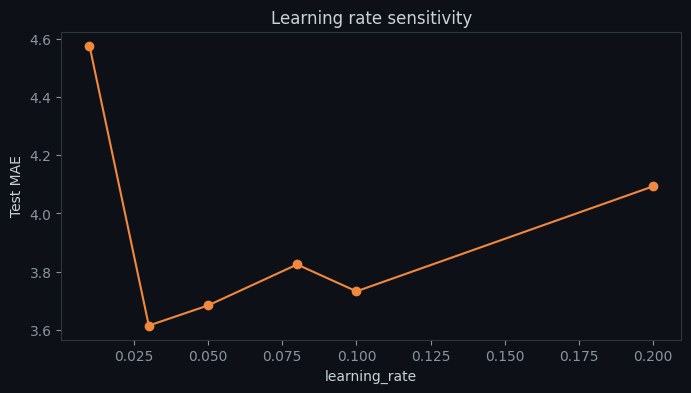

In [11]:
lrs=[0.01,0.03,0.05,0.08,0.1,0.2]
maes=[]
for lr in lrs:
    m=xgb.XGBRegressor(**{k:v for k,v in best_params.items() if k!="learning_rate"},learning_rate=lr,random_state=42,device="cuda")
    m.fit(X_train,y_train)
    maes.append(mean_absolute_error(y_test,m.predict(X_test)))
plt.figure(figsize=(8,4))
plt.plot(lrs,maes,"o-",color="#f0883e")
plt.xlabel("learning_rate");plt.ylabel("Test MAE");plt.title("Learning rate sensitivity")
save_fig("lr_sensitivity")


  Saved plots/learning_curve_2026-05-27_17-21.png


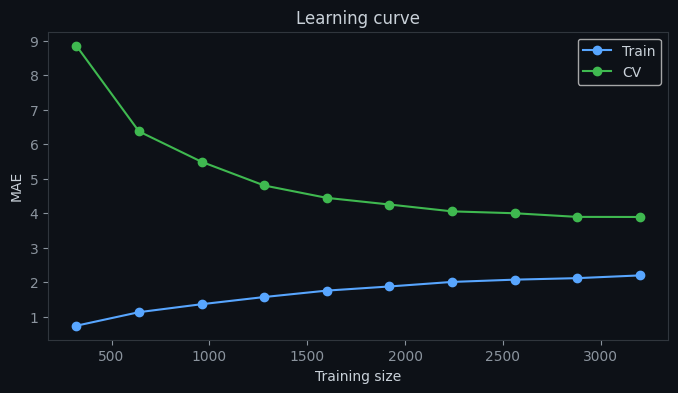

In [12]:
train_sizes,train_scores,val_scores=learning_curve(
    xgb.XGBRegressor(**best_params,random_state=42,device="cuda"),
    X_train,y_train,cv=5,train_sizes=np.linspace(0.1,1.0,10),scoring="neg_mean_absolute_error",n_jobs=-1)
plt.figure(figsize=(8,4))
plt.plot(train_sizes,-train_scores.mean(axis=1),"o-",label="Train",color="#58a6ff")
plt.plot(train_sizes,-val_scores.mean(axis=1),"o-",label="CV",color="#3fb950")
plt.xlabel("Training size");plt.ylabel("MAE");plt.title("Learning curve");plt.legend()
save_fig("learning_curve")


  Saved plots/residuals_2026-05-27_17-21.png
Test MAE: 3.6151  R2: 0.9867

MAE by category:
  work: 4.31 (n=235)
  health: 3.39 (n=102)
  personal: 2.62 (n=236)
  study: 3.46 (n=164)
  errand: 2.43 (n=145)
  social: 6.08 (n=118)


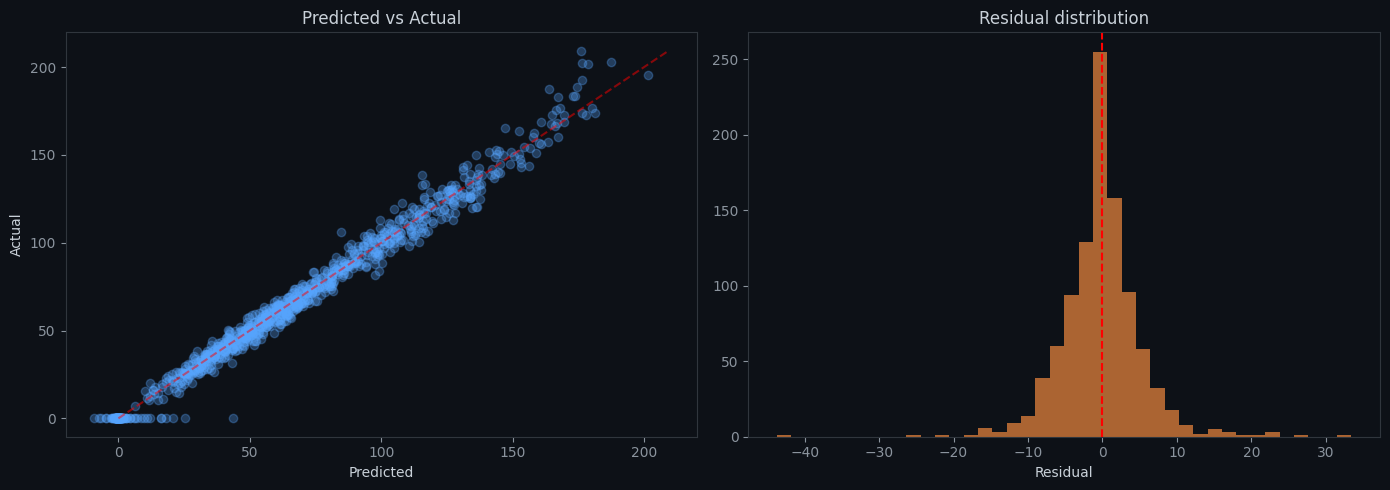

In [13]:
model=xgb.XGBRegressor(**best_params,random_state=42,device="cuda")
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].scatter(y_pred,y_test,alpha=0.3,color="#58a6ff")
axes[0].plot([0,y_test.max()],[0,y_test.max()],"r--",alpha=0.5)
axes[0].set_xlabel("Predicted");axes[0].set_ylabel("Actual");axes[0].set_title("Predicted vs Actual")
residuals=y_test-y_pred
axes[1].hist(residuals,bins=40,color="#f0883e",alpha=0.7)
axes[1].axvline(0,color="red",linestyle="--")
axes[1].set_xlabel("Residual");axes[1].set_title("Residual distribution")
plt.tight_layout()
save_fig("residuals")
print(f"Test MAE: {mean_absolute_error(y_test,y_pred):.4f}  R2: {r2_score(y_test,y_pred):.4f}")
cats=preprocessor.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(cat_feats)
X_cat=X_test[:,-len(cats):]
cat_preds=X_cat.argmax(axis=1)
test_cats=train.iloc[y_test.index]["category"].values
print()
print("MAE by category:")
for c in train["category"].unique():
    mask=test_cats==c
    if mask.sum():
        print(f"  {c}: {mean_absolute_error(y_test.values[mask],y_pred[mask]):.2f} (n={mask.sum()})")


In [14]:
from sklearn.ensemble import RandomForestClassifier
y_bin=(y>0).astype(int)
Xb_train,Xb_test,yb_train,yb_test=train_test_split(X_proc,y_bin,test_size=0.2,random_state=42)
clf=RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,n_jobs=-1)
clf.fit(Xb_train,yb_train)
yb_pred=clf.predict(Xb_test)
print(f"Accuracy:  {accuracy_score(yb_test,yb_pred):.4f}")
print(f"Precision: {precision_score(yb_test,yb_pred):.4f}")
print(f"Recall:    {recall_score(yb_test,yb_pred):.4f}")
print(f"F1:        {f1_score(yb_test,yb_pred):.4f}")
print("Confusion matrix:")
print(confusion_matrix(yb_test,yb_pred))


Accuracy:  0.9800
Precision: 0.9758
Recall:    1.0000
F1:        0.9877
Confusion matrix:
[[175  20]
 [  0 805]]


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (16,) and arg 3 with shape (20,).

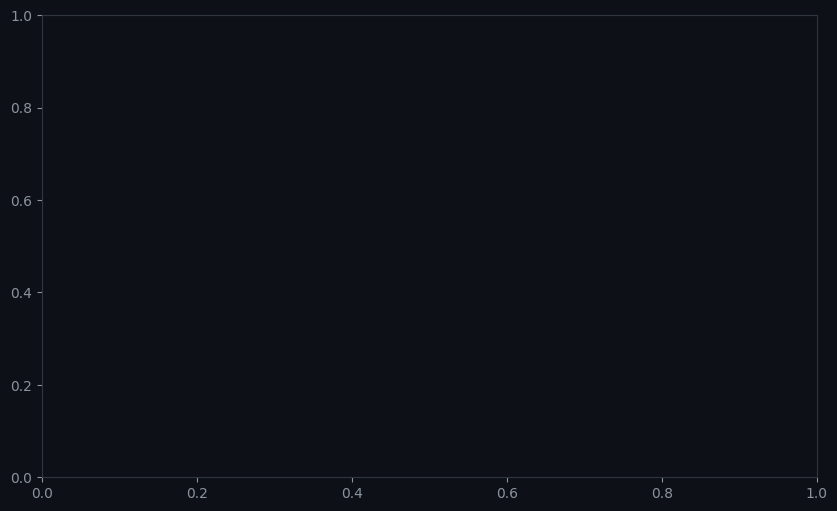

In [16]:
importances=model.feature_importances_
idx=np.argsort(importances)[::-1][:20]
plt.figure(figsize=(10,6))
plt.barh(range(20),importances[idx][::-1],color="#58a6ff")
plt.yticks(range(20),[feat_names[i] for i in idx][::-1])
plt.xlabel("importance");plt.title("Top 20 features")
save_fig("feature_importance")


In [18]:
cv=KFold(n_splits=5,shuffle=True,random_state=42)
maes=[]
for fold,(tr_idx,val_idx) in enumerate(cv.split(X_proc)):
    X_tr_f,X_val_f=X_proc[tr_idx],X_proc[val_idx]
    y_tr_f,y_val_f=y.iloc[tr_idx],y.iloc[val_idx]
    m=xgb.XGBRegressor(**best_params,random_state=42,device="cuda")
    m.fit(X_tr_f,y_tr_f)
    p=m.predict(X_val_f)
    mae=mean_absolute_error(y_val_f,p)
    maes.append(mae)
    print(f"  Fold {fold+1}: MAE={mae:.4f}  R2={r2_score(y_val_f,p):.4f}")
print(f"5-Fold CV MAE: {np.mean(maes):.4f} +/- {np.std(maes):.4f}")


  Fold 1: MAE=3.6162  R2=0.9862
  Fold 2: MAE=3.7574  R2=0.9852
  Fold 3: MAE=3.8110  R2=0.9844
  Fold 4: MAE=3.9730  R2=0.9735
  Fold 5: MAE=3.5075  R2=0.9868
5-Fold CV MAE: 3.7330 +/- 0.1605


In [19]:
final_pipe=Pipeline([("preprocessor",preprocessor),("model",model)])
final_pipe.fit(X,y)
joblib.dump(final_pipe,"duration_predictor.pkl")
print("Saved duration_predictor.pkl")


Saved duration_predictor.pkl


In [20]:
from google.colab import files
files.download("duration_predictor.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>